In [1]:
!conda env list


# conda environments:
#
# * -> active
# + -> frozen
base                     C:\Users\sanka\miniconda3
singlecell               C:\Users\sanka\miniconda3\envs\singlecell



In [1]:
!conda activate singlecell

In [2]:
!pip install scanpy
!pip install scvi-tools


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import scanpy as sc
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scvi as scvi
from IPython.display import display

W0613 17:05:52.705000 2696 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [2]:
sc.settings.verbosity = 1

In [3]:
os.getcwd()

'C:\\Users\\sanka\\Desktop\\SingleCell_github\\scripts'

In [4]:
os.chdir('C:\\Users\\sanka\\Desktop\\SingleCell_github\\')

In [5]:
results_file = 'results/pbmc3k.h5ad'

# Load data 

In [6]:
# Read matrix [Counts, Barcodes(cells), and Features(Genes)]
adata = sc.read_10x_mtx(r"C:\Users\sanka\Desktop\SingleCell_github\data\pbmc3k_filtered_gene_bc_matrices\filtered_gene_bc_matrices\hg19")

In [7]:
# # Make the var(gene) name unique 
adata.var_names_make_unique()

In [8]:
#  Checking whether the names are unique now or not 
adata.var_names.is_unique

True

# EDA

Number of Cells : 2700
Number of Genes : 32738
Sparsity of the data : 97.41 % 

Number of Mitochondrial Genes : 13
Number of Ribosomal Genes : 106
Number of Hemoglobin Genes : 0

Top 20 Genes Expressed


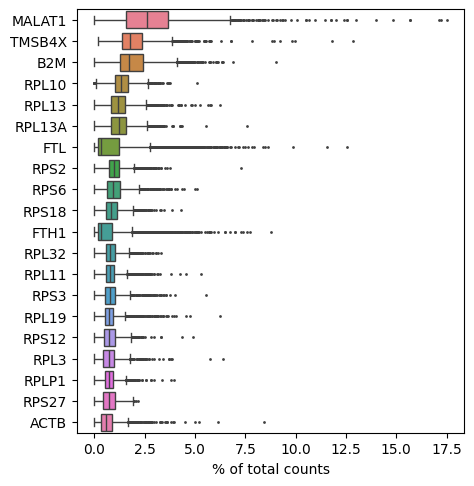



CELL LEVEL QC METRICES SUMMARY 



,n_genes_by_counts,total_counts,pct_counts_Mitochondrial,pct_counts_Ribosomal
count,2700.000000,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132,34.949211
std,282.104964,1094.262085,1.165438,10.215296
min,212.000000,548.000000,0.000000,1.055966
25%,690.000000,1757.750000,1.536238,26.332963
50%,817.000000,2197.000000,2.029639,36.769516
75%,953.250000,2763.000000,2.640218,43.353328
max,3422.000000,15844.000000,22.569027,59.441711


Minimum Number of Genes in a cell : 212
Maximum Number of Genes in a cell : 3422
Number of cell with less than 300 genes expressed : 15
Mitochondrial Percentage Range : 0 % - 23 %  
Ribosomal Percentage Range : 1 % - 59 %  



GENE LEVEL QC METRICES SUMMARY 



,n_cells_by_counts,total_counts
count,32738.000000,32738.000000
mean,69.854114,195.205292
std,238.263898,2301.482666
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,35.000000,37.000000
max,2700.000000,161685.000000


Minimum number of cells in which a gene is expressed : 0
Maximum number of cells in which a gene is expressed : 2700
Number of Genes which are expressed in less than 3 cells : 19024


In [9]:
def EDA(adata):

    print(f"Number of Cells : {len(adata.obs)}")
    print(f"Number of Genes : {len(adata.var)}")

    Total_elements = len(adata.obs)*len(adata.var) 
    Nonzero_elements = adata.X.nnz
    print(f"Sparsity of the data : {((Total_elements-Nonzero_elements)/Total_elements)*100:.2f} % \n")

    # Identification of Mitochondrial, Ribosomal and Hemoglobin Genes
    adata.var["Mitochondrial"] = adata.var_names.str.startswith("MT-")  # MORE MT = DYING CELL BUT DEPENDS UPON THE CELL TYPE 
    adata.var["Ribosomal"] = adata.var_names.str.startswith(("RPS","RPL")) 
    adata.var["Hemo"] = adata.var_names.str.startswith("^HB[^(P)]")

    print(f"Number of Mitochondrial Genes : {(adata.var["Mitochondrial"]).sum()}")
    print(f"Number of Ribosomal Genes : {(adata.var["Ribosomal"]).sum()}")
    print(f"Number of Hemoglobin Genes : {(adata.var["Hemo"]).sum()}\n")

    # PLotting the top 20 highly expressed genes
    print("Top 20 Genes Expressed")
    sc.pl.highest_expr_genes(adata, n_top=20)

    # Calculating per cell level qc metrices
    sc.pp.calculate_qc_metrics(adata,percent_top=None,log1p=False,qc_vars =['Mitochondrial','Ribosomal','Hemo'] ,inplace=True )
    print("\n")  
    
    # CELL LEVEL QC METRICES
    print("CELL LEVEL QC METRICES SUMMARY \n")
    cell_qc = adata.obs[['n_genes_by_counts','total_counts','pct_counts_Mitochondrial','pct_counts_Ribosomal']].describe()
    display(cell_qc)
    print(f"Minimum Number of Genes in a cell : {min(adata.obs['n_genes_by_counts'])}")
    print(f"Maximum Number of Genes in a cell : {max(adata.obs['n_genes_by_counts'])}")
    print(f"Number of cell with less than 300 genes expressed : {(adata.obs['n_genes_by_counts'] < 300 ).sum()}")
    print(f"Mitochondrial Percentage Range : {min(adata.obs['pct_counts_Mitochondrial']):.0f} % - {max(adata.obs['pct_counts_Mitochondrial']):.0f} %  ")
    print(f"Ribosomal Percentage Range : {min(adata.obs['pct_counts_Ribosomal']):.0f} % - {max(adata.obs['pct_counts_Ribosomal']):.0f} %  ")
    print("\n\n")  

    # GENE LEVEL METRICES 
    print("GENE LEVEL QC METRICES SUMMARY \n")
    gene_qc = adata.var[['n_cells_by_counts','total_counts']].describe()
    display(gene_qc)
    print(f"Minimum number of cells in which a gene is expressed : {min(adata.var["n_cells_by_counts"])}")
    print(f"Maximum number of cells in which a gene is expressed : {max(adata.var["n_cells_by_counts"])}")
    print(f"Number of Genes which are expressed in less than 3 cells : {(adata.var["n_cells_by_counts"] < 3).sum()}")

    summary_stats = {
    "n_cells": len(adata.obs),
    "n_genes": len(adata.var),
    "sparsity": ((Total_elements-Nonzero_elements)/Total_elements)*100,
    "n_mt_genes": adata.var["Mitochondrial"].sum(),
    "n_ribo_genes": adata.var["Ribosomal"].sum(),
    "n_hemo_genes": adata.var["Hemo"].sum(),
    "cells_lt_300_genes": (adata.obs['n_genes_by_counts'] < 300).sum(),
    "genes_lt_3_cells": (adata.var["n_cells_by_counts"] < 3).sum()
    }

    return summary_stats, cell_qc, gene_qc

summary_stats , cell_qc , gene_qc = EDA(adata)

In [10]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_Ribosomal', 'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo'
    var: 'gene_ids', 'Mitochondrial', 'Ribosomal', 'Hemo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

#### Visualizing QC Metrices

In [11]:
# Plotting QC Metrices 

def Plotting(adata): 

    # Figure path 
    figure_path = 'Figures/'
    
    # Setting the figure and axes objects for a 3x1 grid
    fig, axes = plt.subplots(nrows=1, ncols=6 , figsize=(45, 8))

    # FIGURE 1A : GENES DISTRIBUTION
    fig_1 = axes[0]
    fig_1.hist(adata.obs['n_genes_by_counts'], bins = 50, alpha= 0.7 , color='steelblue',edgecolor='black')
    fig_1.set_xlabel("Genes per cell")
    fig_1.set_ylabel("Number of cells")
    fig_1.set_title("Gene Distribution")
    fig_1.axvline(np.median(adata.obs['n_genes_by_counts']), color = 'red', linestyle = '--', label = f"Median {np.median(adata.obs['n_genes_by_counts']):.0f}")
    fig_1.legend()

    # FIGURE 1B : GENE DISTRIBUTION VIOLIN PLOT  
    ax1_viol = axes[1]
    sc.pl.violin(adata, "n_genes_by_counts", jitter=0.4, ax=ax1_viol, show=False )
    ax1_viol.set_title("Genes per cell (Violin Plot)")
    ax1_viol.set_xlabel("") # Clear redundant x-label

    # FIGURE 2A : UMI DISTRIBUTION
    fig_2 = axes[2]
    fig_2.hist(adata.obs['total_counts'], bins = 50, alpha= 0.7 , color='yellow',edgecolor='black')
    fig_2.set_xlabel("UMI per cell")
    fig_2.set_ylabel("Number of cells")
    fig_2.set_title("UMI Distribution")
    fig_2.axvline(np.median(adata.obs['total_counts']), color = 'red', linestyle = '--', label = f"Median {np.median(adata.obs['total_counts']):.0f}")
    fig_2.legend()

    # FIGURE 2B : UMI DISTRIBUTION Violin Plot
    ax2_viol = axes[3]
    sc.pl.violin(adata, "total_counts", jitter=0.4, ax=ax2_viol, show=False)
    ax2_viol.set_title("UMI Counts per cell (Violin Plot)")
    ax2_viol.set_xlabel("")
    
    # FIGURE 3A : MITOCHONDRIAL DISTRIBUITON
    fig_3 = axes[4]
    fig_3.hist(adata.obs['pct_counts_Mitochondrial'], bins = 50, alpha= 0.7 , color='green',edgecolor='black')
    fig_3.set_xlabel("Mitochondrial % per cell")
    fig_3.set_ylabel("Number of cells")
    fig_3.set_title("Mitochondiral Distribution")
    fig_3.axvline(np.median(adata.obs['pct_counts_Mitochondrial']), color = 'red', linestyle = '--', label = f"Median {np.median(adata.obs['pct_counts_Mitochondrial']):.2f} %")
    fig_3.legend()

    # FIGURE 3B : MITOCHONDRIAL DITRIBUTION VIOLIN PLOT
    ax3_viol = axes[5]
    sc.pl.violin(adata, "pct_counts_Mitochondrial", jitter=0.4, ax=ax3_viol, show=False)
    ax3_viol.set_title("Mitochondrial % (Violin Plot)")
    ax3_viol.set_xlabel("")

    plt.savefig(f"{figure_path}/01_qc_plots.png" ,bbox_inches="tight")
    plt.close()

Plotting(adata)

## Preprocessing | Quality Control

### Basic filtering based on Graphs

In [12]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_Ribosomal', 'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo'
    var: 'gene_ids', 'Mitochondrial', 'Ribosomal', 'Hemo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [13]:
adata_qc = adata.copy()

In [14]:
# Cell filtering 
sc.pp.filter_cells(adata_qc,min_genes = 200)
sc.pp.filter_cells(adata_qc,max_genes = 2500)

# Gene filtering 
sc.pp.filter_genes(adata_qc,min_cells = 3 )  # ~58 % of genes are not expressed in 3 cells | 32738 - 19024 = 13714

In [15]:
adata_qc

AnnData object with n_obs × n_vars = 2695 × 13673
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_Ribosomal', 'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo', 'n_genes'
    var: 'gene_ids', 'Mitochondrial', 'Ribosomal', 'Hemo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [16]:
# Removing Mitochondrial and Ribosomal Genes  
adata_qc = adata_qc[adata_qc.obs['pct_counts_Mitochondrial'] < 5 , : ]
# adata_qc = adata_qc[adata_qc.obs['pct_counts_Ribosomal'] > 5 , : ]


In [17]:
adata_qc

View of AnnData object with n_obs × n_vars = 2638 × 13673
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_Ribosomal', 'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo', 'n_genes'
    var: 'gene_ids', 'Mitochondrial', 'Ribosomal', 'Hemo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [18]:
print(f"Cells Before filtering : {len(adata.obs)}")
print(f"Genes Before filtering : {len(adata.var)}\n ")

print(f"Cells after filtering : {len(adata_qc.obs)}")
print(f"Genes after filtering : {len(adata_qc.var)}")

Cells Before filtering : 2700
Genes Before filtering : 32738
 
Cells after filtering : 2638
Genes after filtering : 13673


In [19]:
adata_qc.obs_names.is_unique

True

## Doublet Detection - SCRUBLET

In [18]:
!pip install scikit-image


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
sc.pp.scrublet(adata_qc)

C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\preprocessing\_scrublet\__init__.py:297: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["doublet_score"] = scrubbed["obs"]["doublet_score"]


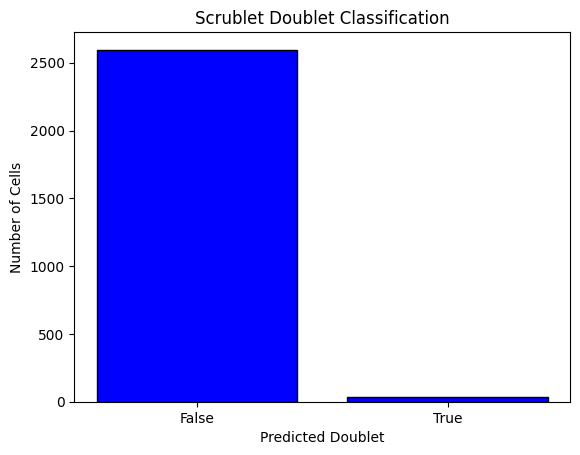

predicted_doublet
False    2596
True       32
Name: predicted_doublet, dtype: int64


In [21]:
# Checking how many Cells are marked as doublets using scrublet
scrublet_doublets = (adata_qc.obs['predicted_doublet'].groupby(adata_qc.obs['predicted_doublet'])).count()
plt.bar(scrublet_doublets.index.astype(str),
        scrublet_doublets.values,
        color='blue',
        edgecolor='black')

plt.xlabel('Predicted Doublet')
plt.ylabel('Number of Cells')
plt.title('Scrublet Doublet Classification')
plt.savefig('Figures/02_doublet_detection_scrublet.png')
plt.show()

print(scrublet_doublets)

# Normalisation

In [20]:
adata_qc.layers['counts'] = adata_qc.X.copy()

C:\Users\sanka\AppData\Local\Temp\ipykernel_2696\1416119010.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_qc.layers['counts'] = adata_qc.X.copy()


In [21]:
sc.pp.normalize_total(adata_qc , target_sum = 1e4 )

In [22]:
sc.pp.log1p(adata_qc)

# HVG

In [23]:
sc.pp.highly_variable_genes(
    adata_qc,
    flavor="seurat_v3",
    n_top_genes=2000,
    layer="counts"
)

C:\Users\sanka\AppData\Local\Temp\ipykernel_2696\3302737342.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.highly_variable_genes(adata_qc, save='highly_variable_genes.png')


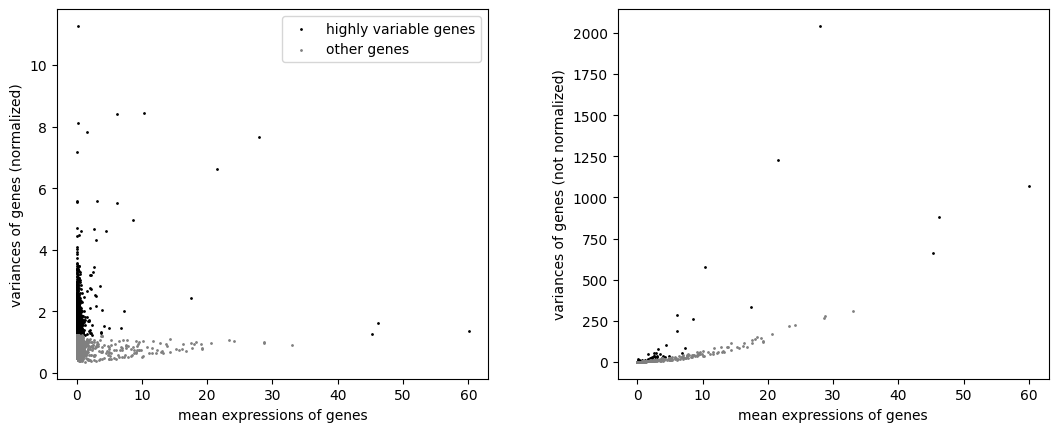

In [48]:
sc.pl.highly_variable_genes(adata_qc, save='highly_variable_genes.png')

In [30]:
adata_qc = adata_qc[:, adata_qc.var.highly_variable] 

In [31]:
adata_qc = adata_qc.copy()

In [25]:
adata_qc.is_view

False

## Doublet Detection - SCVI TOOLS

In [26]:
import scvi

In [27]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 3050 Laptop GPU


In [37]:
scvi.model.SCVI.setup_anndata(adata_qc, layers = 'counts')
vae = scvi.model.SCVI(adata_qc)
vae.train(accelerator = 'gpu' , devices = 1)

C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scvi\data\fields\_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\sanka\AppData\Local\Program

Training:   0%|          | 0/400 [00:00<?, ?it/s]

C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_

In [38]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train(accelerator = 'gpu' , devices = 1)

INFO     Creating doublets, preparing SOLO model.                                                                  


C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scvi\data\fields\_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many wor

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.009. Signaling Trainer to stop.


In [40]:
solo_doublets = solo.predict()
solo_doublets['Prediction'] = solo.predict(soft=False)

solo_doublets.groupby('Prediction').count()

C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,doublet,singlet
Prediction,,
doublet,6,6
singlet,2616,2616


In [41]:
adata_qc.obs['Solo_prediction'] = solo_doublets['Prediction']

In [42]:
adata_qc

AnnData object with n_obs × n_vars = 2622 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_Ribosomal', 'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo', 'n_genes', 'doublet_score', 'predicted_doublet', '_scvi_batch', '_scvi_labels', 'Solo_prediction'
    var: 'gene_ids', 'Mitochondrial', 'Ribosomal', 'Hemo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'scrublet', 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid'
    layers: 'counts'

# Doublet Removal

In [30]:
adata_qc = adata_qc[~adata_qc.obs.predicted_doublet]

In [33]:
adata_qc

AnnData object with n_obs × n_vars = 2628 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_Ribosomal', 'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo', 'n_genes'
    var: 'gene_ids', 'Mitochondrial', 'Ribosomal', 'Hemo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [34]:
# Regression removes unwanted technical effects
sc.pp.regress_out(adata_qc, ['total_counts','pct_counts_Mitochondrial','pct_counts_Ribosomal'])

In [35]:
# Scaling sets every gene on a same variance scale 
sc.pp.scale(adata_qc, max_value = 10)

# Dimensionality Reduction

In [26]:
# Calculating PCs 
sc.tl.pca(adata_qc)

# BY DEFAULT IT CALCULATES 50 PCs
# Results stored in adata_qc.obsm["X_pca"]

C:\Users\sanka\AppData\Local\Temp\ipykernel_2696\4285427793.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata_qc, n_pcs = 50 , log = True , save = '03_dimensional_reduction.png')


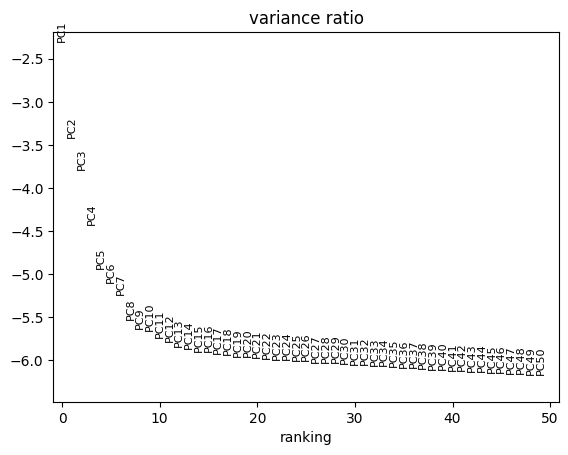

In [27]:
sc.pl.pca_variance_ratio(adata_qc, n_pcs = 50 , log = True , save = '03_dimensional_reduction.png')

C:\Users\sanka\AppData\Local\Temp\ipykernel_2696\1289364845.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_loadings(adata_qc, components=(1, 2), include_lowest=True,save = '05_PC1_PC2_contributions.png' )


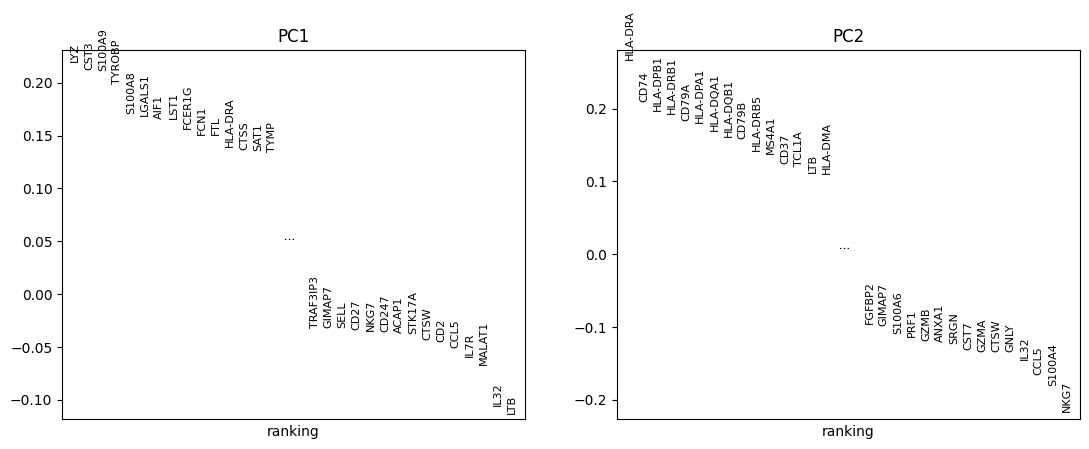

In [28]:
# Checking which genes contributes to pca1 and pca2 
sc.pl.pca_loadings(adata_qc, components=(1, 2), include_lowest=True,save = '05_PC1_PC2_contributions.png' )

In [29]:
adata_qc

AnnData object with n_obs × n_vars = 2638 × 13673
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_Ribosomal', 'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo', 'n_genes'
    var: 'gene_ids', 'Mitochondrial', 'Ribosomal', 'Hemo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

# Computing the neighborhood graph

In [30]:
sc.pp.neighbors(adata_qc, n_neighbors=10, n_pcs=40)

# Embedding the Neighbourhood Graph

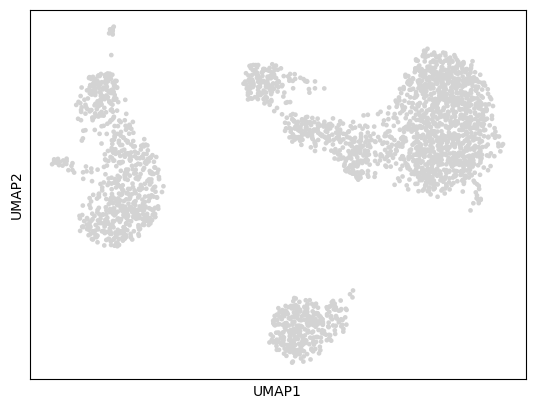

In [31]:
sc.tl.umap(adata_qc)
sc.pl.umap(adata_qc)

In [32]:
# Doublets checking using UMAP 
# sc.pl.umap(adata_qc , color = ["doublet_score",'predicted_doublet'])

# Clustering 

In [33]:
!pip install leidenalg


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
# Clustering Using the Leiden Algorithm 
sc.tl.leiden(adata_qc, resolution = 0.7,flavor = "igraph" , n_iterations = 2 )

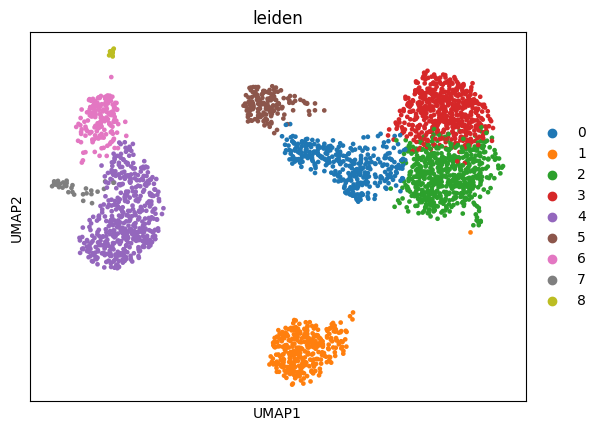

In [35]:
sc.pl.umap(adata_qc , color = "leiden", show = False)
plt.savefig('Figures/04_Leiden_clustering.png')
plt.show()

# Alternative code : sc.pl.umap(adata_qc , color = "leiden", save = 'Figures/04_Leiden_clustering.png')

# Cell Type annotation

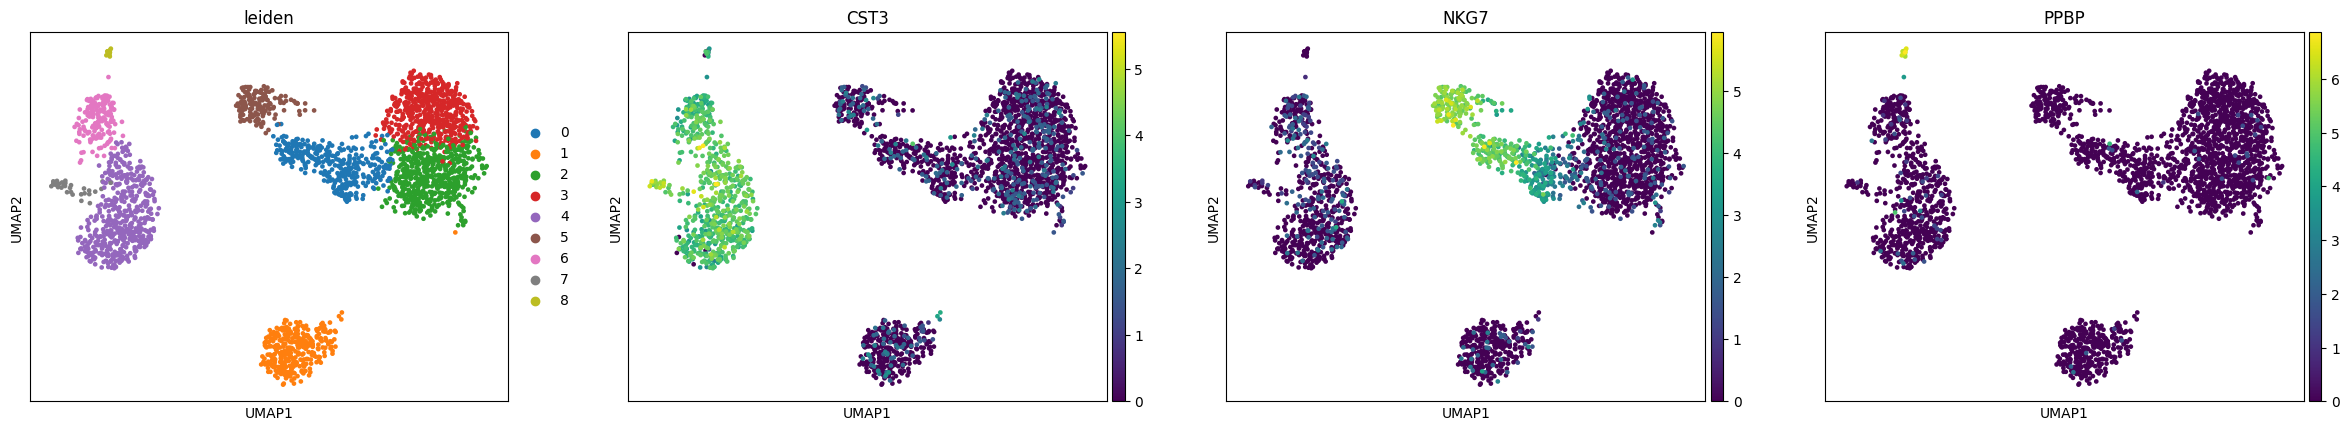

In [36]:
sc.pl.umap(adata_qc , color = ["leiden","CST3","NKG7","PPBP"])

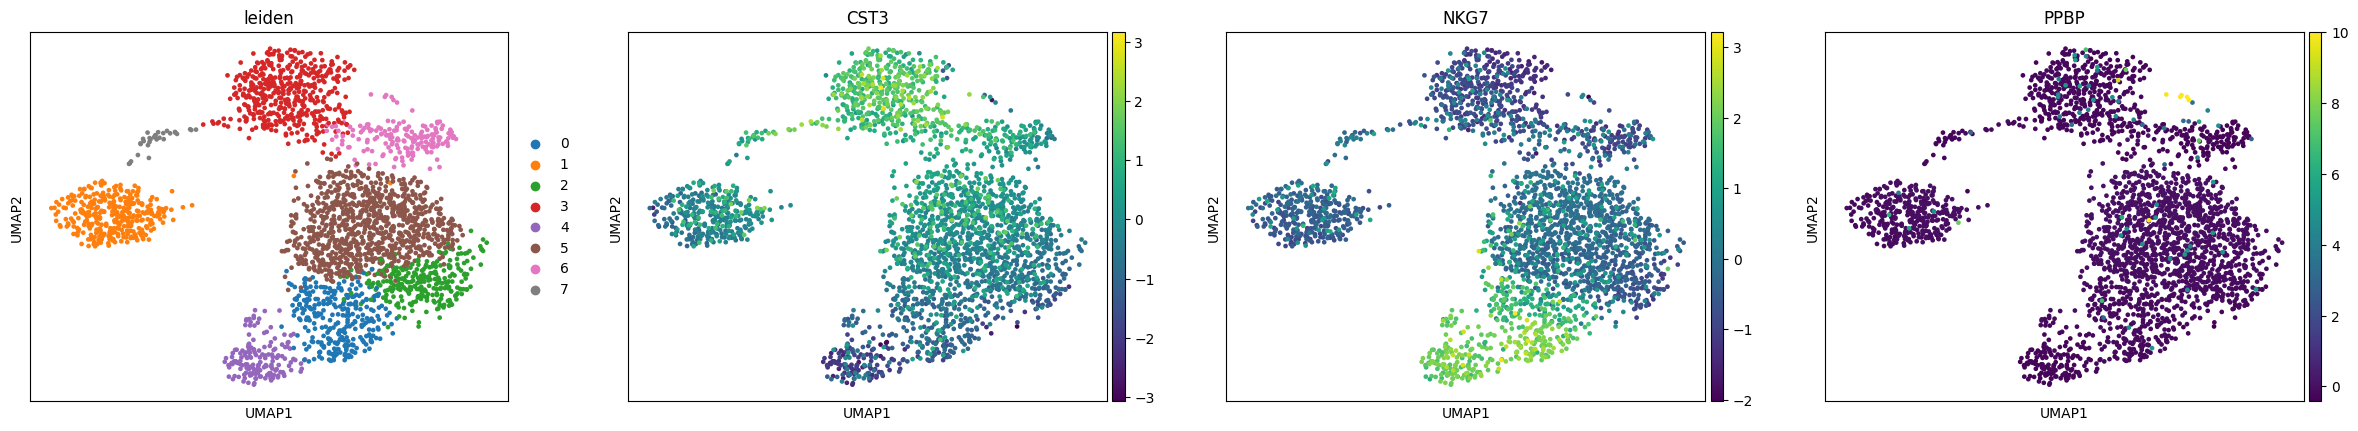

In [46]:
sc.pl.umap(adata_qc , color = ["leiden","CST3","NKG7","PPBP"])

C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\sanka\AppData\Local\Programs\Python\Python314\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: inv

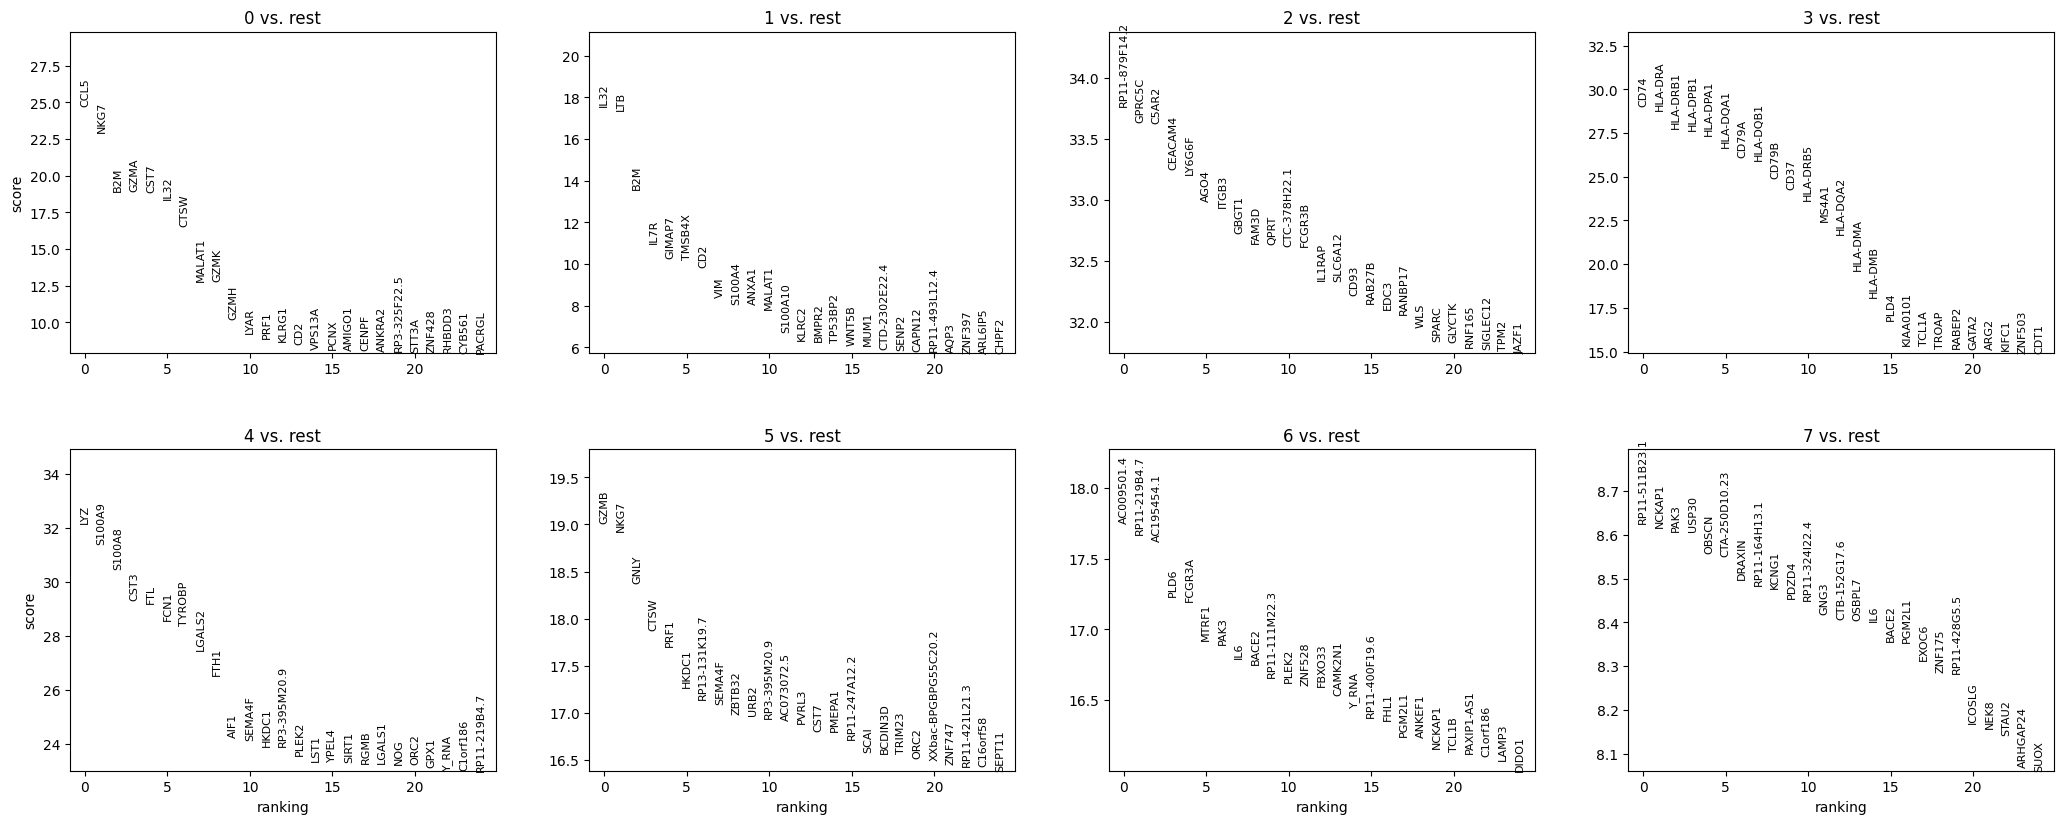

In [50]:
sc.tl.rank_genes_groups(adata_qc, "leiden", mask_var="highly_variable", method='wilcoxon')
sc.pl.rank_genes_groups(adata_qc, n_genes=25, sharey=False)

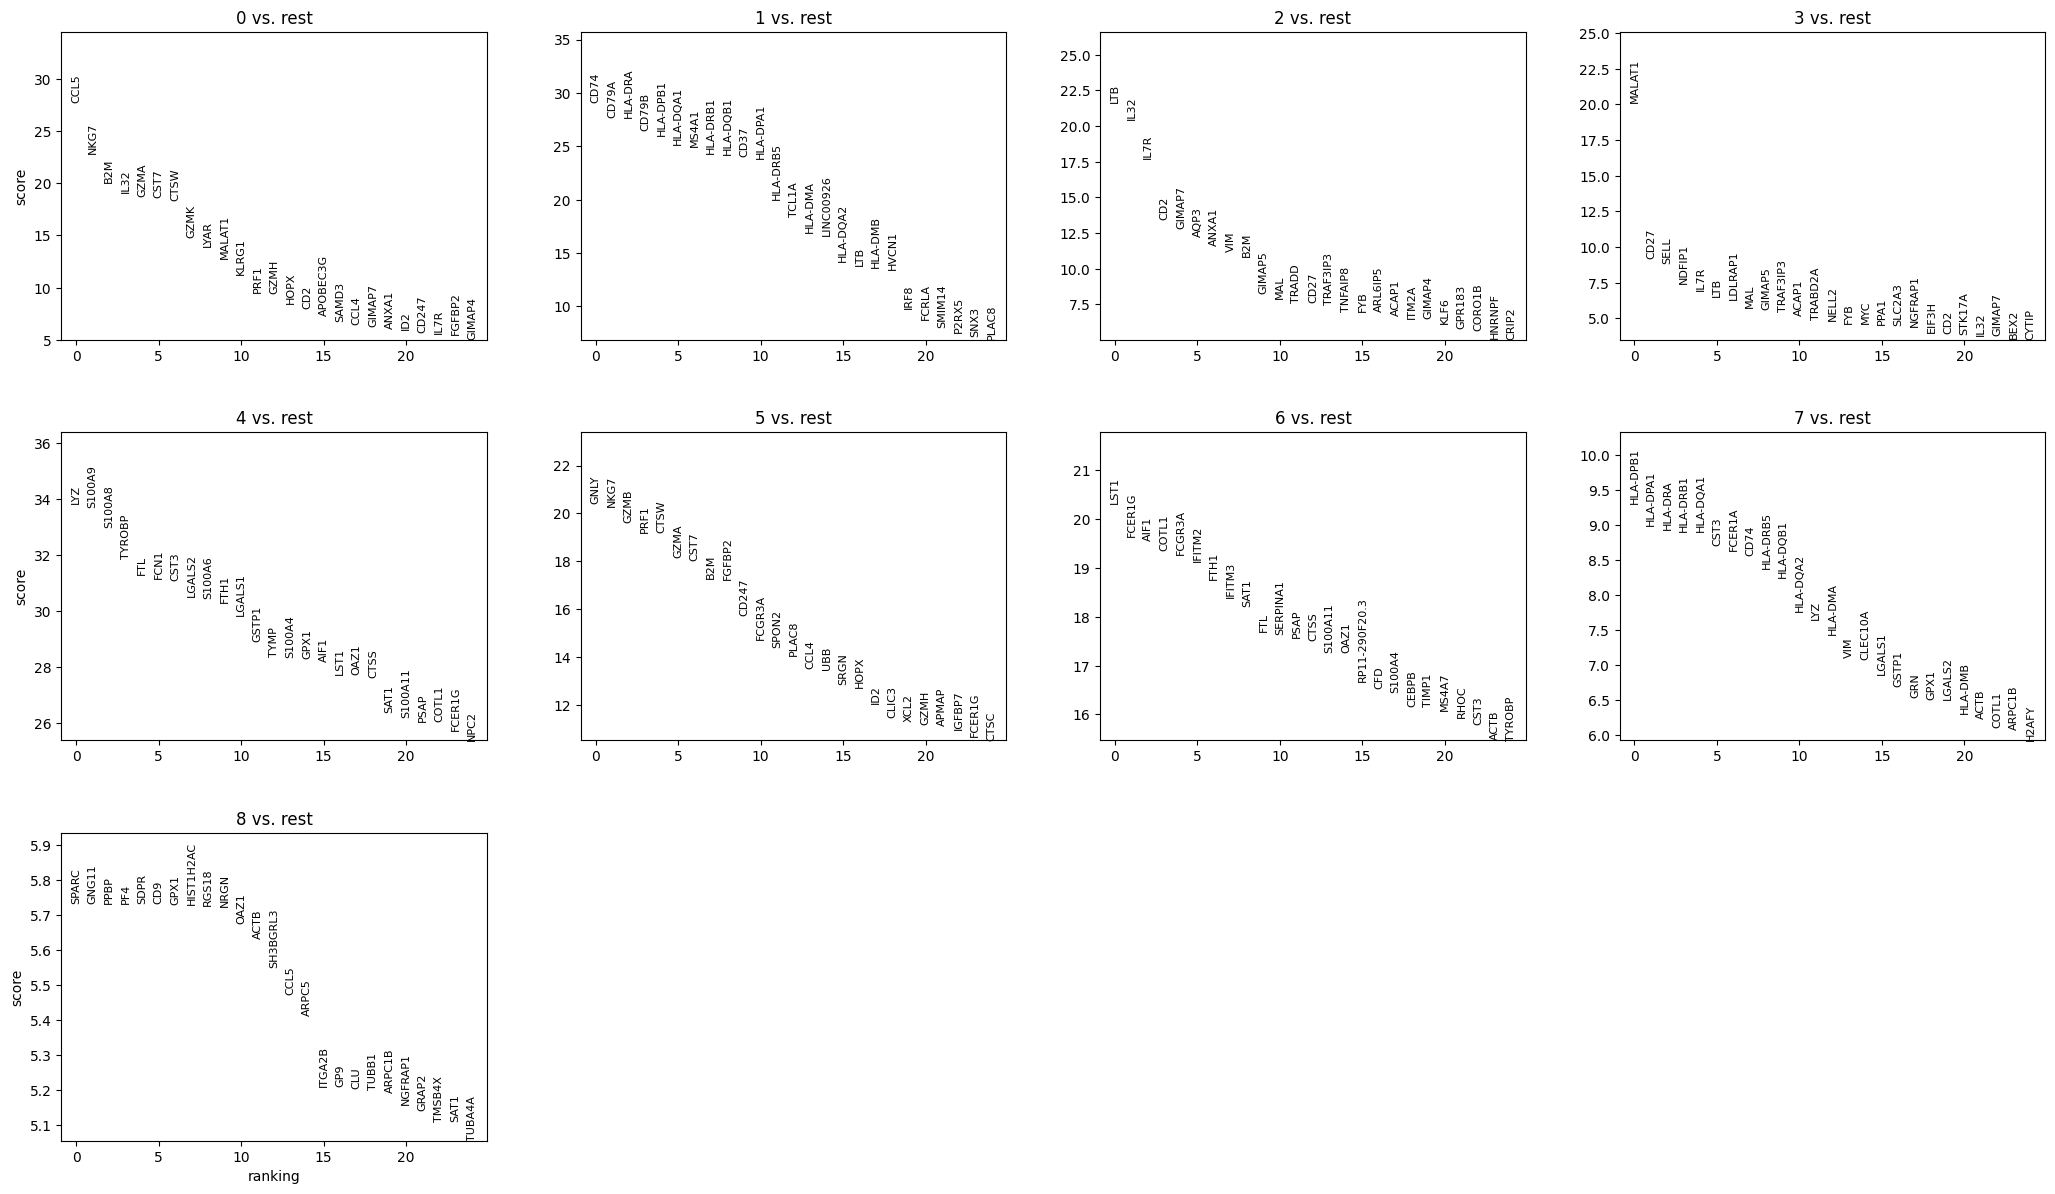

In [37]:
sc.tl.rank_genes_groups(adata_qc, "leiden", mask_var="highly_variable", method='wilcoxon')
sc.pl.rank_genes_groups(adata_qc, n_genes=25, sharey=False)

In [38]:
# Top 10 Expressed genes in clusters
pd.DataFrame(adata_qc.uns['rank_genes_groups']['names']).head(10)

,0,1,2,3,4,5,6,7,8
0,CCL5,CD74,LTB,MALAT1,LYZ,GNLY,LST1,HLA-DPB1,SPARC
1,NKG7,CD79A,IL32,CD27,S100A9,NKG7,FCER1G,HLA-DPA1,GNG11
2,B2M,HLA-DRA,IL7R,SELL,S100A8,GZMB,AIF1,HLA-DRA,PPBP
3,IL32,CD79B,CD2,NDFIP1,TYROBP,PRF1,COTL1,HLA-DRB1,PF4
4,GZMA,HLA-DPB1,GIMAP7,IL7R,FTL,CTSW,FCGR3A,HLA-DQA1,SDPR
5,CST7,HLA-DQA1,AQP3,LTB,FCN1,GZMA,IFITM2,CST3,CD9
6,CTSW,MS4A1,ANXA1,LDLRAP1,CST3,CST7,FTH1,FCER1A,GPX1
7,GZMK,HLA-DRB1,VIM,MAL,LGALS2,B2M,IFITM3,CD74,HIST1H2AC
8,LYAR,HLA-DQB1,B2M,GIMAP5,S100A6,FGFBP2,SAT1,HLA-DRB5,RGS18
9,MALAT1,CD37,GIMAP5,TRAF3IP3,FTH1,CD247,FTL,HLA-DQB1,NRGN


In [50]:
adata_qc.var.loc["PPBP", ["highly_variable"]]

highly_variable    True
Name: PPBP, dtype: object

In [49]:
adata..columns

Index(['n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial',
       'pct_counts_Mitochondrial', 'total_counts_Ribosomal',
       'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo'],
      dtype='object')

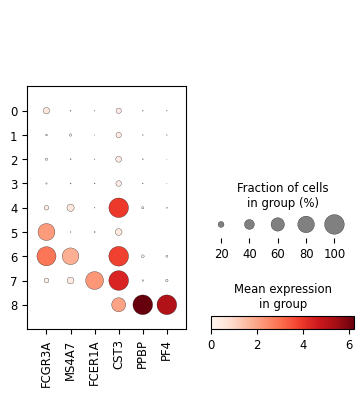

In [39]:
sc.pl.dotplot(
    adata_qc,
    ["FCGR3A","MS4A7","FCER1A","CST3","PPBP","PF4"],
    groupby="leiden"
)

In [58]:
adata_qc.obs["leiden"].value_counts()

leiden
5    899
3    464
1    342
0    290
2    271
6    174
4    158
7     30
Name: count, dtype: int64

In [57]:
adata_qc.write(results_file)

In [59]:
adata_qc

AnnData object with n_obs × n_vars = 2628 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_Ribosomal', 'pct_counts_Ribosomal', 'total_counts_Hemo', 'pct_counts_Hemo', 'n_genes', 'leiden'
    var: 'gene_ids', 'Mitochondrial', 'Ribosomal', 'Hemo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'